         Date     Product  Quantity  Price Customer_ID Region  Total_Sales
0  2024-01-01       Phone         7  37300     CUST001   East       261100
1  2024-01-02  Headphones         4  15406     CUST002  North        61624
2  2024-01-03       Phone         2  21746     CUST003   West        43492
3  2024-01-04  Headphones         1  30895     CUST004   East        30895
4  2024-01-05      Laptop         8  39835     CUST005  North       318680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         100 non-null    object
 1   Product      100 non-null    object
 2   Quantity     100 non-null    int64 
 3   Price        100 non-null    int64 
 4   Customer_ID  100 non-null    object
 5   Region       100 non-null    object
 6   Total_Sales  100 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 5.6+ KB
None
         Quantity      

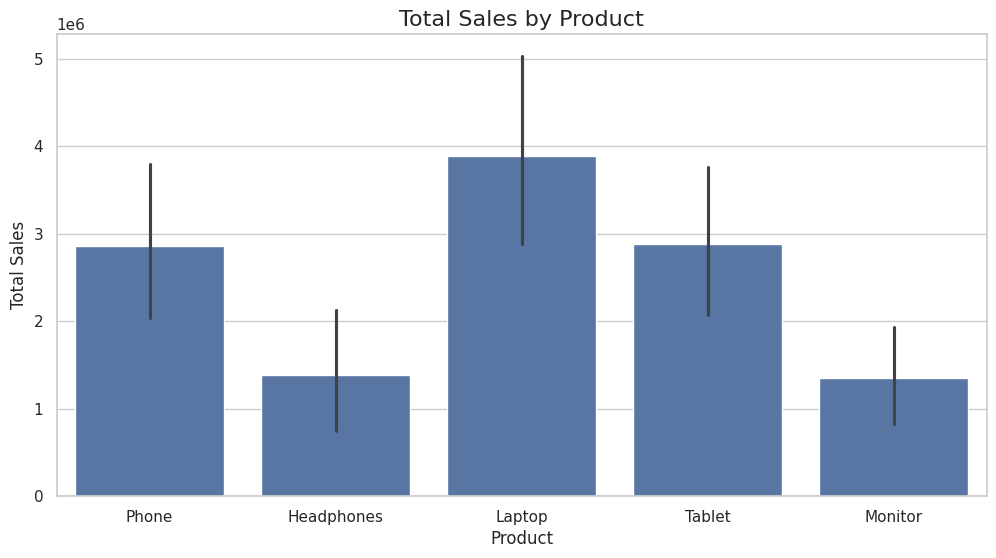

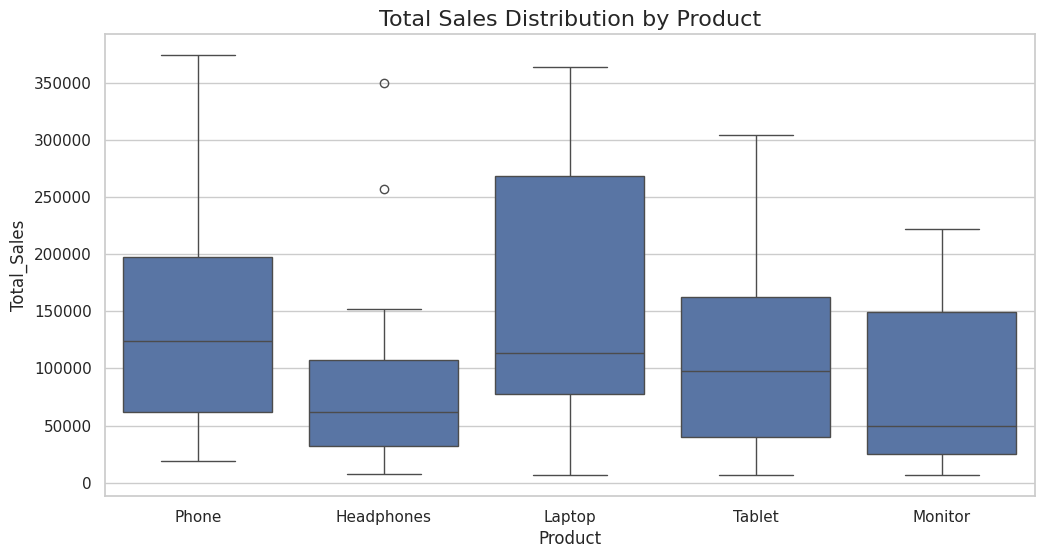

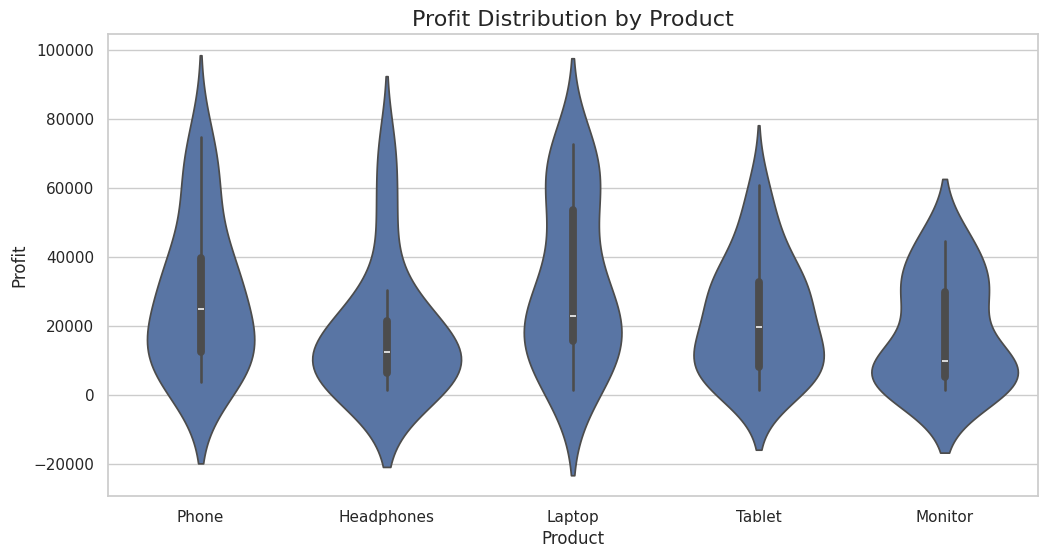

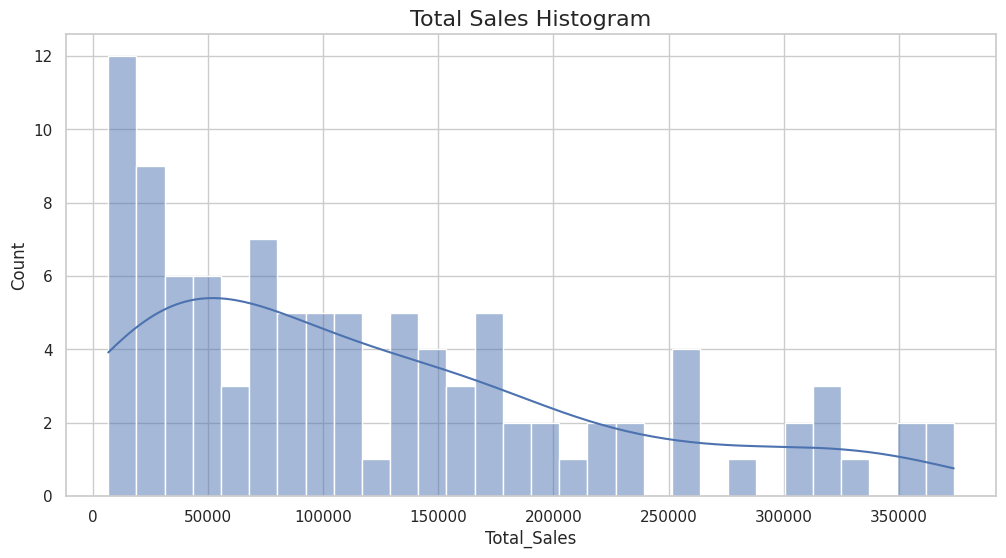

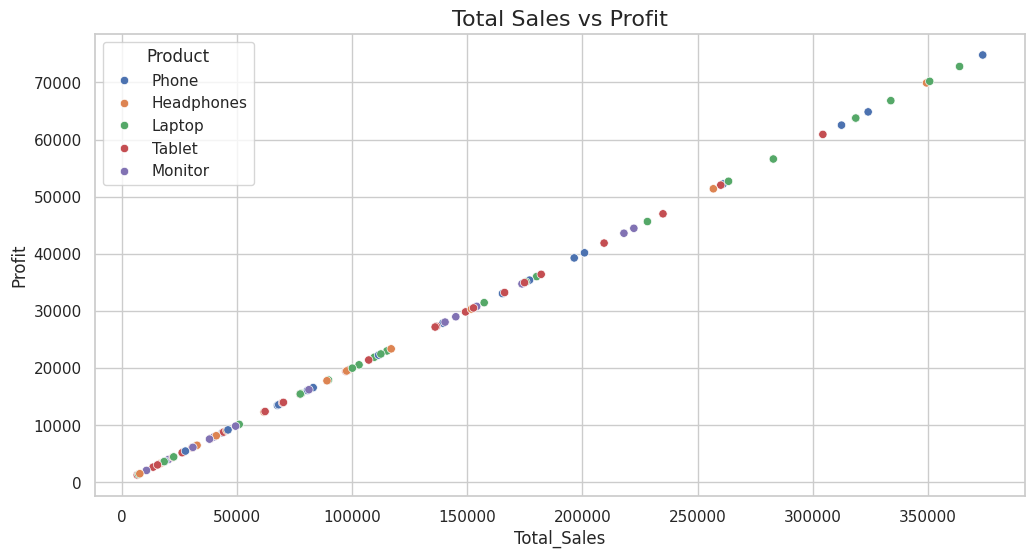

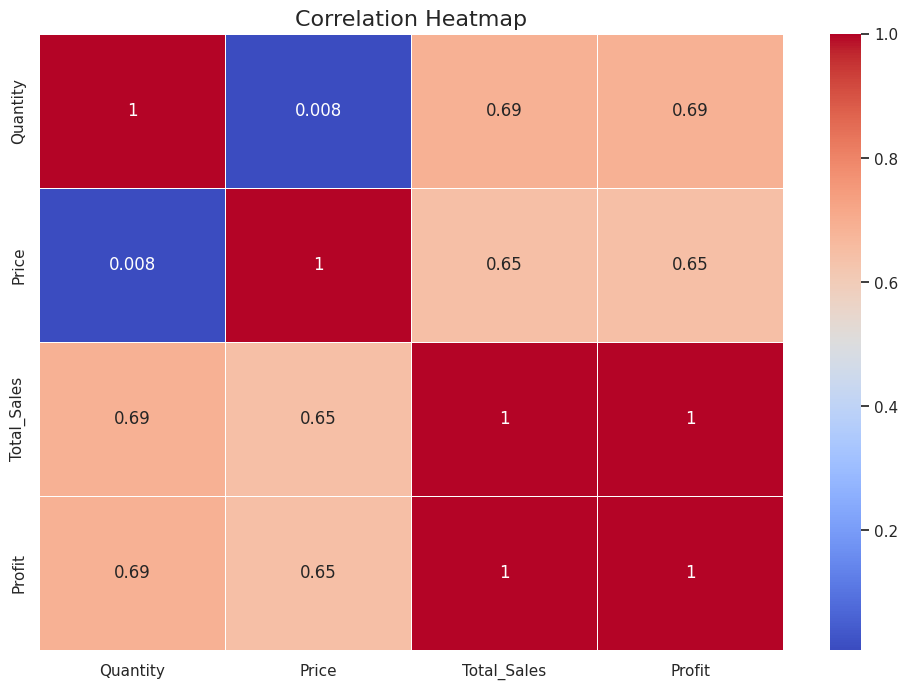

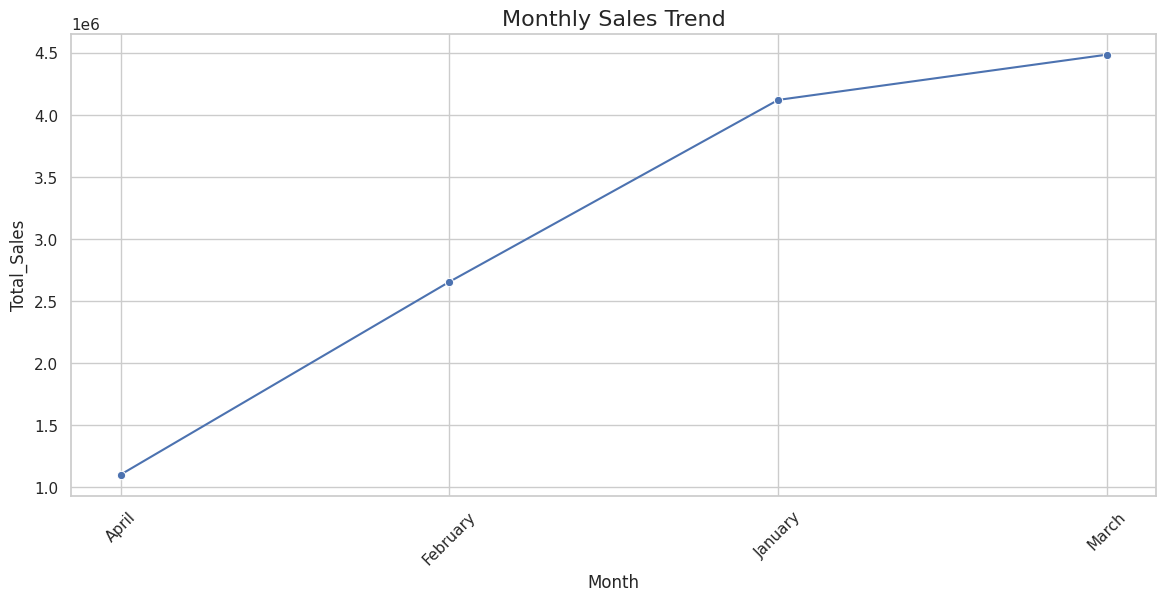

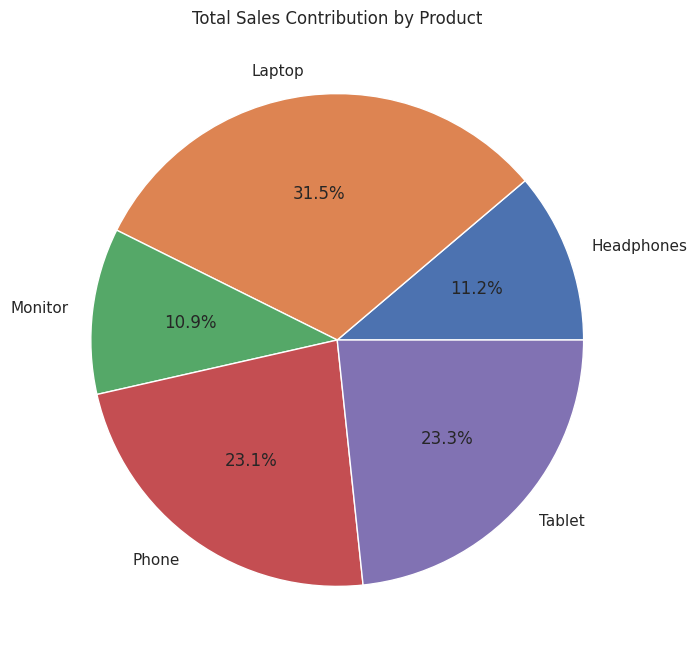

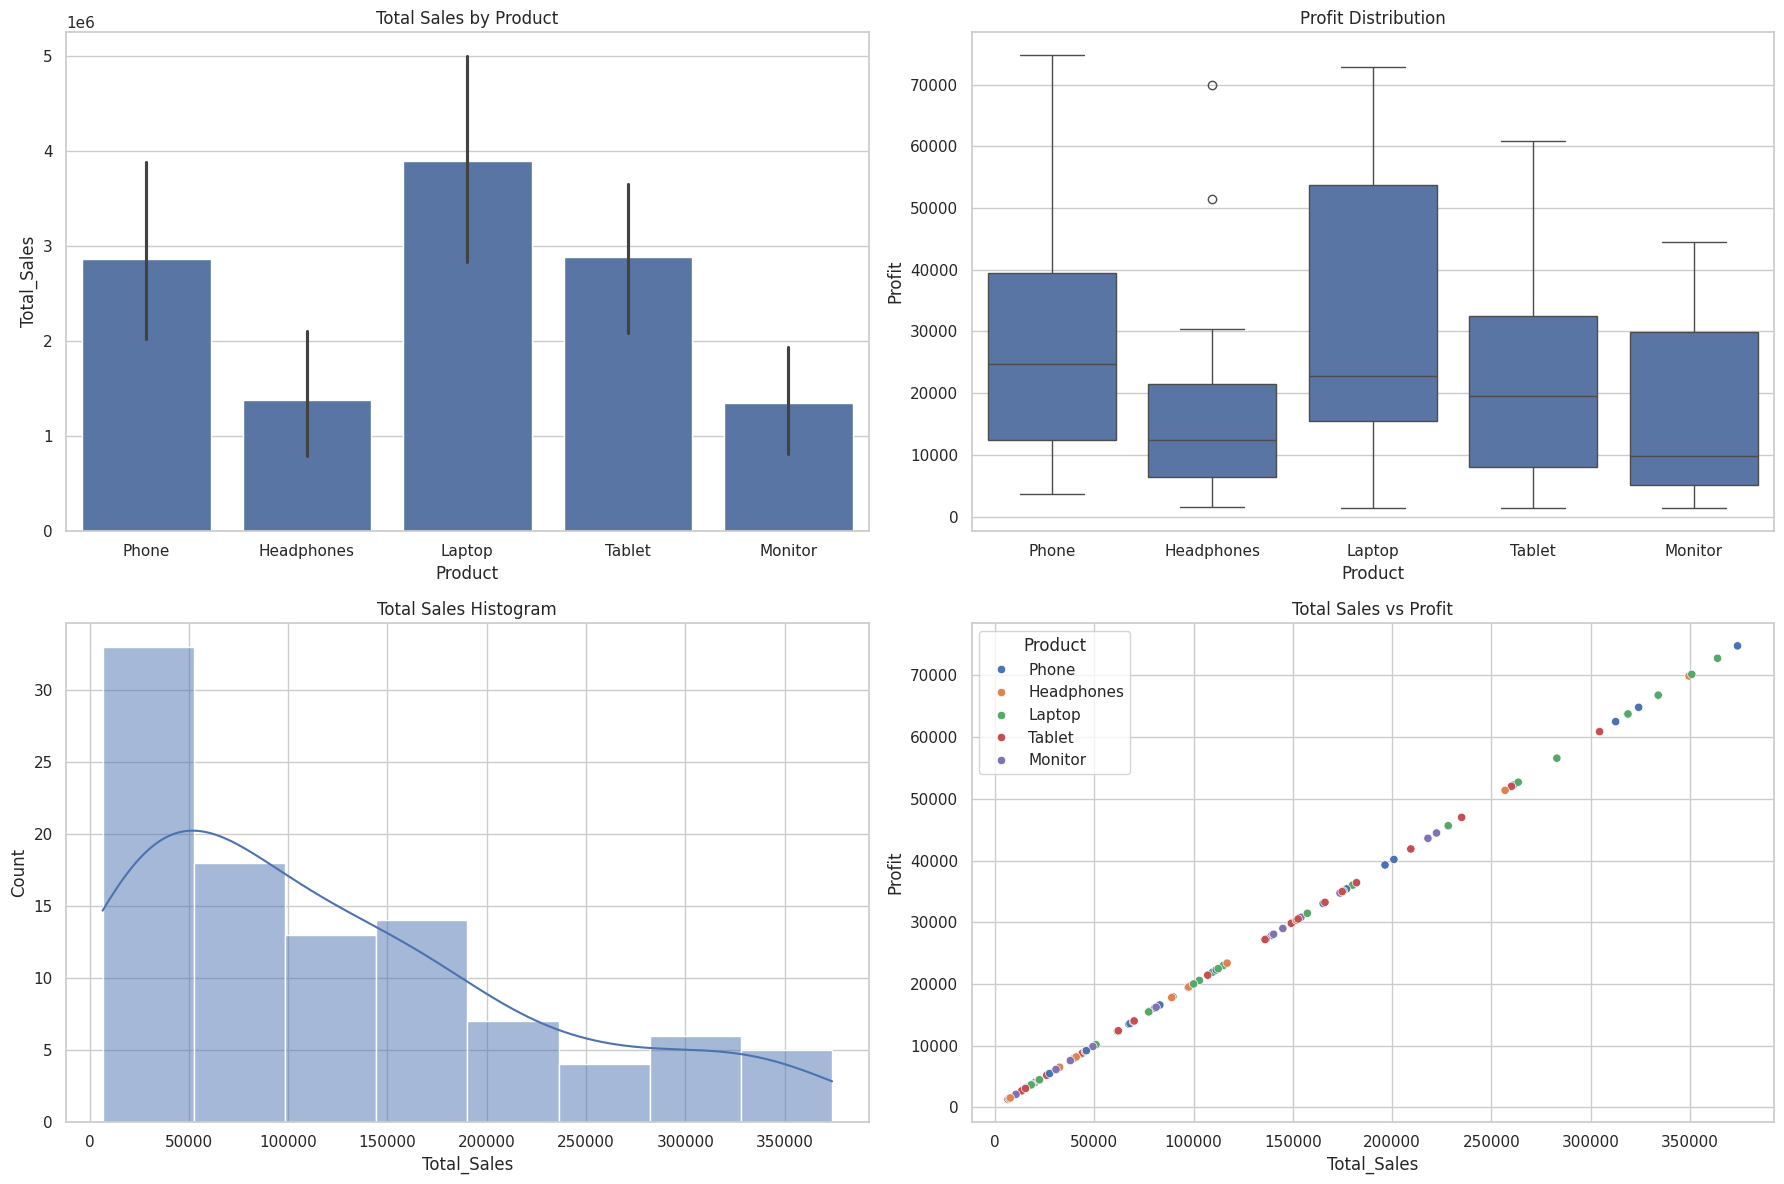


================ KPI METRICS ================

Total Sales: 12365048
Total Profit: 2473009.5999999996
Average Sales: 123650.48
Total Orders: 100



Dashboard Project Completed Successfully!


In [7]:
# ============================================================
# INTERACTIVE SALES DASHBOARD PROJECT
# Week 6 - Data Visualization Mastery
# ============================================================

# =========================
# IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os

# =========================
# CREATE VISUALIZATIONS DIRECTORY
# =========================

if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

# =========================
# LOAD DATASET
# =========================

df = pd.read_csv("sales_data.csv")

# =========================
# DISPLAY BASIC INFO
# =========================

print(df.head())

print(df.info())

print(df.describe())

# =========================
# HANDLE MISSING VALUES
# =========================

df.dropna(inplace=True)

# =========================
# CALCULATE PROFIT (since it's not in the original dataset)
# =========================
# Assuming a simple profit margin, for example, 20% of Total_Sales.
# You can adjust this calculation based on your business logic if actual cost data is available.
df['Profit'] = df['Total_Sales'] * 0.20

# =========================
# CONVERT DATE COLUMN
# =========================

# Replace with your actual date column name
df['Date'] = pd.to_datetime(df['Date'])

# =========================
# CREATE MONTH COLUMN
# =========================

df['Month'] = df['Date'].dt.month_name()

# =========================
# SEABORN STYLE
# =========================

sns.set_theme(style="whitegrid")

# ============================================================
# 1. BAR CHART - SALES BY CATEGORY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    x='Product',
    y='Total_Sales',
    data=df,
    estimator=sum
)

plt.title("Total Sales by Product", fontsize=16)
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.savefig("visualizations/bar_chart_sales.png")

plt.show()

# ============================================================
# 2. BOX PLOT - SALES DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x='Product',
    y='Total_Sales',
    data=df
)

plt.title("Total Sales Distribution by Product", fontsize=16)

plt.savefig("visualizations/boxplot_sales.png")

plt.show()

# ============================================================
# 3. VIOLIN PLOT - PROFIT DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.violinplot(
    x='Product',
    y='Profit',
    data=df
)

plt.title("Profit Distribution by Product", fontsize=16)

plt.savefig("visualizations/violin_plot.png")

plt.show()

# ============================================================
# 4. HISTOGRAM - SALES DISTRIBUTION
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Total_Sales'],
    kde=True,
    bins=30
)

plt.title("Total Sales Histogram", fontsize=16)

plt.savefig("visualizations/histogram_sales.png")

plt.show()

# ============================================================
# 5. SCATTER PLOT - SALES VS PROFIT
# ============================================================

plt.figure(figsize=(12,6))

sns.scatterplot(
    x='Total_Sales',
    y='Profit',
    hue='Product',
    data=df
)

plt.title("Total Sales vs Profit", fontsize=16)

plt.savefig("visualizations/scatterplot.png")

plt.show()

# ============================================================
# 6. HEATMAP - CORRELATION MATRIX
# ============================================================

corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=16)

plt.savefig("visualizations/heatmap.png")

plt.show()

# ============================================================
# 7. LINE CHART - SALES TREND
# ============================================================

# Sort by date to ensure correct trend line
df_sorted = df.sort_values(by='Date')
monthly_sales = df_sorted.groupby('Month')['Total_Sales'].sum().reset_index()

plt.figure(figsize=(14,6))

sns.lineplot(
    x='Month',
    y='Total_Sales',
    data=monthly_sales,
    marker='o'
)

plt.title("Monthly Sales Trend", fontsize=16)

plt.xticks(rotation=45)

plt.savefig("visualizations/linechart_sales.png")

plt.show()

# ============================================================
# 8. PIE CHART - CATEGORY CONTRIBUTION
# ============================================================

category_sales = df.groupby('Product')['Total_Sales'].sum()

plt.figure(figsize=(8,8))

plt.pie(
    category_sales,
    labels=category_sales.index,
    autopct='%1.1f%%'
)

plt.title("Total Sales Contribution by Product")

plt.savefig("visualizations/piechart.png")

plt.show()

# ============================================================
# 9. MULTI-PLOT DASHBOARD
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(18,12))

# BAR CHART
sns.barplot(
    ax=axes[0,0],
    x='Product',
    y='Total_Sales',
    data=df,
    estimator=sum
)

axes[0,0].set_title("Total Sales by Product")

# BOX PLOT
sns.boxplot(
    ax=axes[0,1],
    x='Product',
    y='Profit',
    data=df
)

axes[0,1].set_title("Profit Distribution")

# HISTOGRAM
sns.histplot(
    ax=axes[1,0],
    data=df['Total_Sales'],
    kde=True
)

axes[1,0].set_title("Total Sales Histogram")

# SCATTER PLOT
sns.scatterplot(
    ax=axes[1,1],
    x='Total_Sales',
    y='Profit',
    hue='Product',
    data=df
)

axes[1,1].set_title("Total Sales vs Profit")

plt.tight_layout()

plt.savefig("visualizations/dashboard_layout.png")

plt.show()

# ============================================================
# 10. KPI METRICS
# ============================================================

total_sales = df['Total_Sales'].sum()

total_profit = df['Profit'].sum()

average_sales = df['Total_Sales'].mean()

total_orders = df['Customer_ID'].nunique() # Assuming unique Customer_ID means unique orders for simplicity, adjust if 'Order ID' column exists

print("\n================ KPI METRICS ================\n")

print(f"Total Sales: {total_sales}")

print(f"Total Profit: {total_profit}")

print(f"Average Sales: {average_sales}")

print(f"Total Orders: {total_orders}")

# ============================================================
# 11. INTERACTIVE PLOTLY LINE CHART
# ============================================================

fig = px.line(
    df,
    x='Date',
    y='Total_Sales',
    color='Product',
    title='Interactive Sales Trend',
    hover_data=['Profit', 'Product']
)

fig.show()

# ============================================================
# 12. INTERACTIVE BAR CHART
# ============================================================

fig = px.bar(
    df,
    x='Product',
    y='Total_Sales',
    color='Product',
    title='Interactive Sales by Product'
)

fig.show()

# ============================================================
# 13. INTERACTIVE PIE CHART
# ============================================================

fig = px.pie(
    df,
    names='Product',
    values='Total_Sales',
    title='Interactive Product Contribution'
)

fig.show()

# ============================================================
# 14. INTERACTIVE SCATTER PLOT
# ============================================================

fig = px.scatter(
    df,
    x='Total_Sales',
    y='Profit',
    color='Product',
    size='Total_Sales',
    hover_data=['Product'],
    title='Interactive Sales vs Profit'
)

fig.show()

# ============================================================
# 15. INTERACTIVE DASHBOARD WITH SUBPLOTS
# ============================================================

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=(
        "Sales Trend",
        "Sales by Product",
        "Profit Distribution",
        "Sales vs Profit"
    )
)

# LINE CHART
fig.add_trace(
    go.Scatter(
        x=df['Date'],
        y=df['Total_Sales'],
        mode='lines',
        name='Sales Trend'
    ),
    row=1,
    col=1
)

# BAR CHART
category_data = df.groupby('Product')['Total_Sales'].sum().reset_index()

fig.add_trace(
    go.Bar(
        x=category_data['Product'],
        y=category_data['Total_Sales'],
        name='Product Sales'
    ),
    row=1,
    col=2
)

# BOX PLOT
fig.add_trace(
    go.Box(
        y=df['Profit'],
        name='Profit Distribution'
    ),
    row=2,
    col=1
)

# SCATTER PLOT
fig.add_trace(
    go.Scatter(
        x=df['Total_Sales'],
        y=df['Profit'],
        mode='markers',
        name='Sales vs Profit'
    ),
    row=2,
    col=2
)

fig.update_layout(
    height=800,
    width=1200,
    title_text="Interactive Sales Dashboard"
)

fig.show()

# ============================================================
# 16. EXPORT CLEAN DATA
# ============================================================

df.to_csv("cleaned_sales_data.csv", index=False)

print("\nDashboard Project Completed Successfully!")

In [8]:
import shutil

# Create ZIP file
shutil.make_archive('visualizations', 'zip', 'visualizations')

'/content/visualizations.zip'

In [9]:
from google.colab import files

files.download('visualizations.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>